# Prophet Forecasting Playground

This notebook provides an interactive environment to test the cluster-based Prophet model in two different operational modes:
1. **Long-Term Forecast**: Relies solely on seasonal trends, holiday effects, and calendar features. Used for capacity planning.
2. **Day-Ahead Forecast**: Enriched with historical consumption lags (e.g., 24h and 1-week back). Used for short-term operational dispatching.

### Key Features
- **Dual-Mode Pipeline**: Test how adding consumption lags dramatically improves short-term accuracy.
- **Modular Architecture**: Uses decoupled functions from `src/models/prophet_model.py` for preprocessing, training, and inference.
- **Zero Data Leakage**: Scaling is strictly fitted on training data (< 2014).

## 0. Environment Setup

Resolve project-level modules from the `src` directory and load the necessary forecasting functions.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure project root is in path
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Import specialized Prophet functions from correctly named module
from src.models.prophet_model import (
    load_processed_data, 
    preprocess_and_split, 
    train_models, 
    predict_models, 
    evaluate_models,
    save_prophet_artifacts
)
from src.tools.visualization import plot_cluster_portfolio, analyze_time_periods

print("✅ Setup complete. Local prophet modules loaded from src/.")

/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


✅ Setup complete. Local prophet modules loaded from src/.


## 1. Global Data Loading

We load the global processed dataset once. It contains all features, including the raw consumption and weather signals that will be scaled differently depending on the forecast mode.

In [2]:
dataset_path = os.path.join(PROJECT_ROOT, 'Datasets', 'processed_electricity_data.parquet')
df_long = load_processed_data(dataset_path)

print(f"\n Total observations loaded: {len(df_long):,}")

Loading processed data...

 Total observations loaded: 41,548,234


---

## 2. EXPERIMENT A: Long-Term Horizon (Weather Only)

In this mode, the model does NOT see the recent consumption lags. It learns to predict the load based strictly on the time of day, day of week, holidays, and external weather regressors.

In [3]:
# A.1 Prepare Data (Long Term)
train_agg_lt, test_agg_lt, test_raw_lt, scalers_lt, sw_lt, regs_lt = preprocess_and_split(df_long, mode='long_term')

# A.2 Train Cluster Models
models_lt = train_models(train_agg_lt, regs_lt)

# A.3 Predict & Un-scale
results_lt = predict_models(models_lt, test_agg_lt, test_raw_lt, scalers_lt, regs_lt)

# A.4 Evaluate
eval_lt, summary_lt = evaluate_models(results_lt)
display(summary_lt)

Preparing train/test split and scaling (Mode: LONG_TERM)...
Scaling individual clients...


Scaling Clients: 100%|██████████| 369/369 [00:06<00:00, 52.82it/s]


Aggregating data by Cluster for Prophet training...
Training Prophet models for 5 clusters...


Training:   0%|          | 0/5 [00:00<?, ?it/s]12:24:25 - cmdstanpy - INFO - Chain [1] start processing
12:24:41 - cmdstanpy - INFO - Chain [1] done processing
Training:  20%|██        | 1/5 [00:18<01:12, 18.06s/it]12:24:45 - cmdstanpy - INFO - Chain [1] start processing
12:25:15 - cmdstanpy - INFO - Chain [1] done processing
Training:  40%|████      | 2/5 [00:52<01:22, 27.47s/it]12:25:19 - cmdstanpy - INFO - Chain [1] start processing
12:26:25 - cmdstanpy - INFO - Chain [1] done processing
Training:  60%|██████    | 3/5 [02:01<01:33, 46.77s/it]12:26:29 - cmdstanpy - INFO - Chain [1] start processing
12:27:11 - cmdstanpy - INFO - Chain [1] done processing
Training:  80%|████████  | 4/5 [02:47<00:46, 46.36s/it]12:27:15 - cmdstanpy - INFO - Chain [1] start processing
12:28:06 - cmdstanpy - INFO - Chain [1] done processing
Training: 100%|██████████| 5/5 [03:42<00:00, 44.57s/it]


Generating forecasts and un-scaling to raw kW...


Un-scaling Clients: 100%|██████████| 369/369 [00:03<00:00, 92.67it/s] 



Evaluating Portfolio Performance...

--- PROPHET PERFORMANCE BY CLUSTER (BUSINESS ORIENTED) ---

         Portfolio_MAPE  Portfolio_WMAPE
Cluster                                 
0.0               40.89            14.16
1.0               74.26            22.09
2.0              229.28            32.86
3.0               18.16            15.56
4.0               11.38             9.09

Global Portfolio MAPE:  74.79%
Global Portfolio WMAPE: 19.13%


,Portfolio_MAPE,Portfolio_WMAPE
Cluster,,
0.0,40.89,14.16
1.0,74.26,22.09
2.0,229.28,32.86
3.0,18.16,15.56
4.0,11.38,9.09


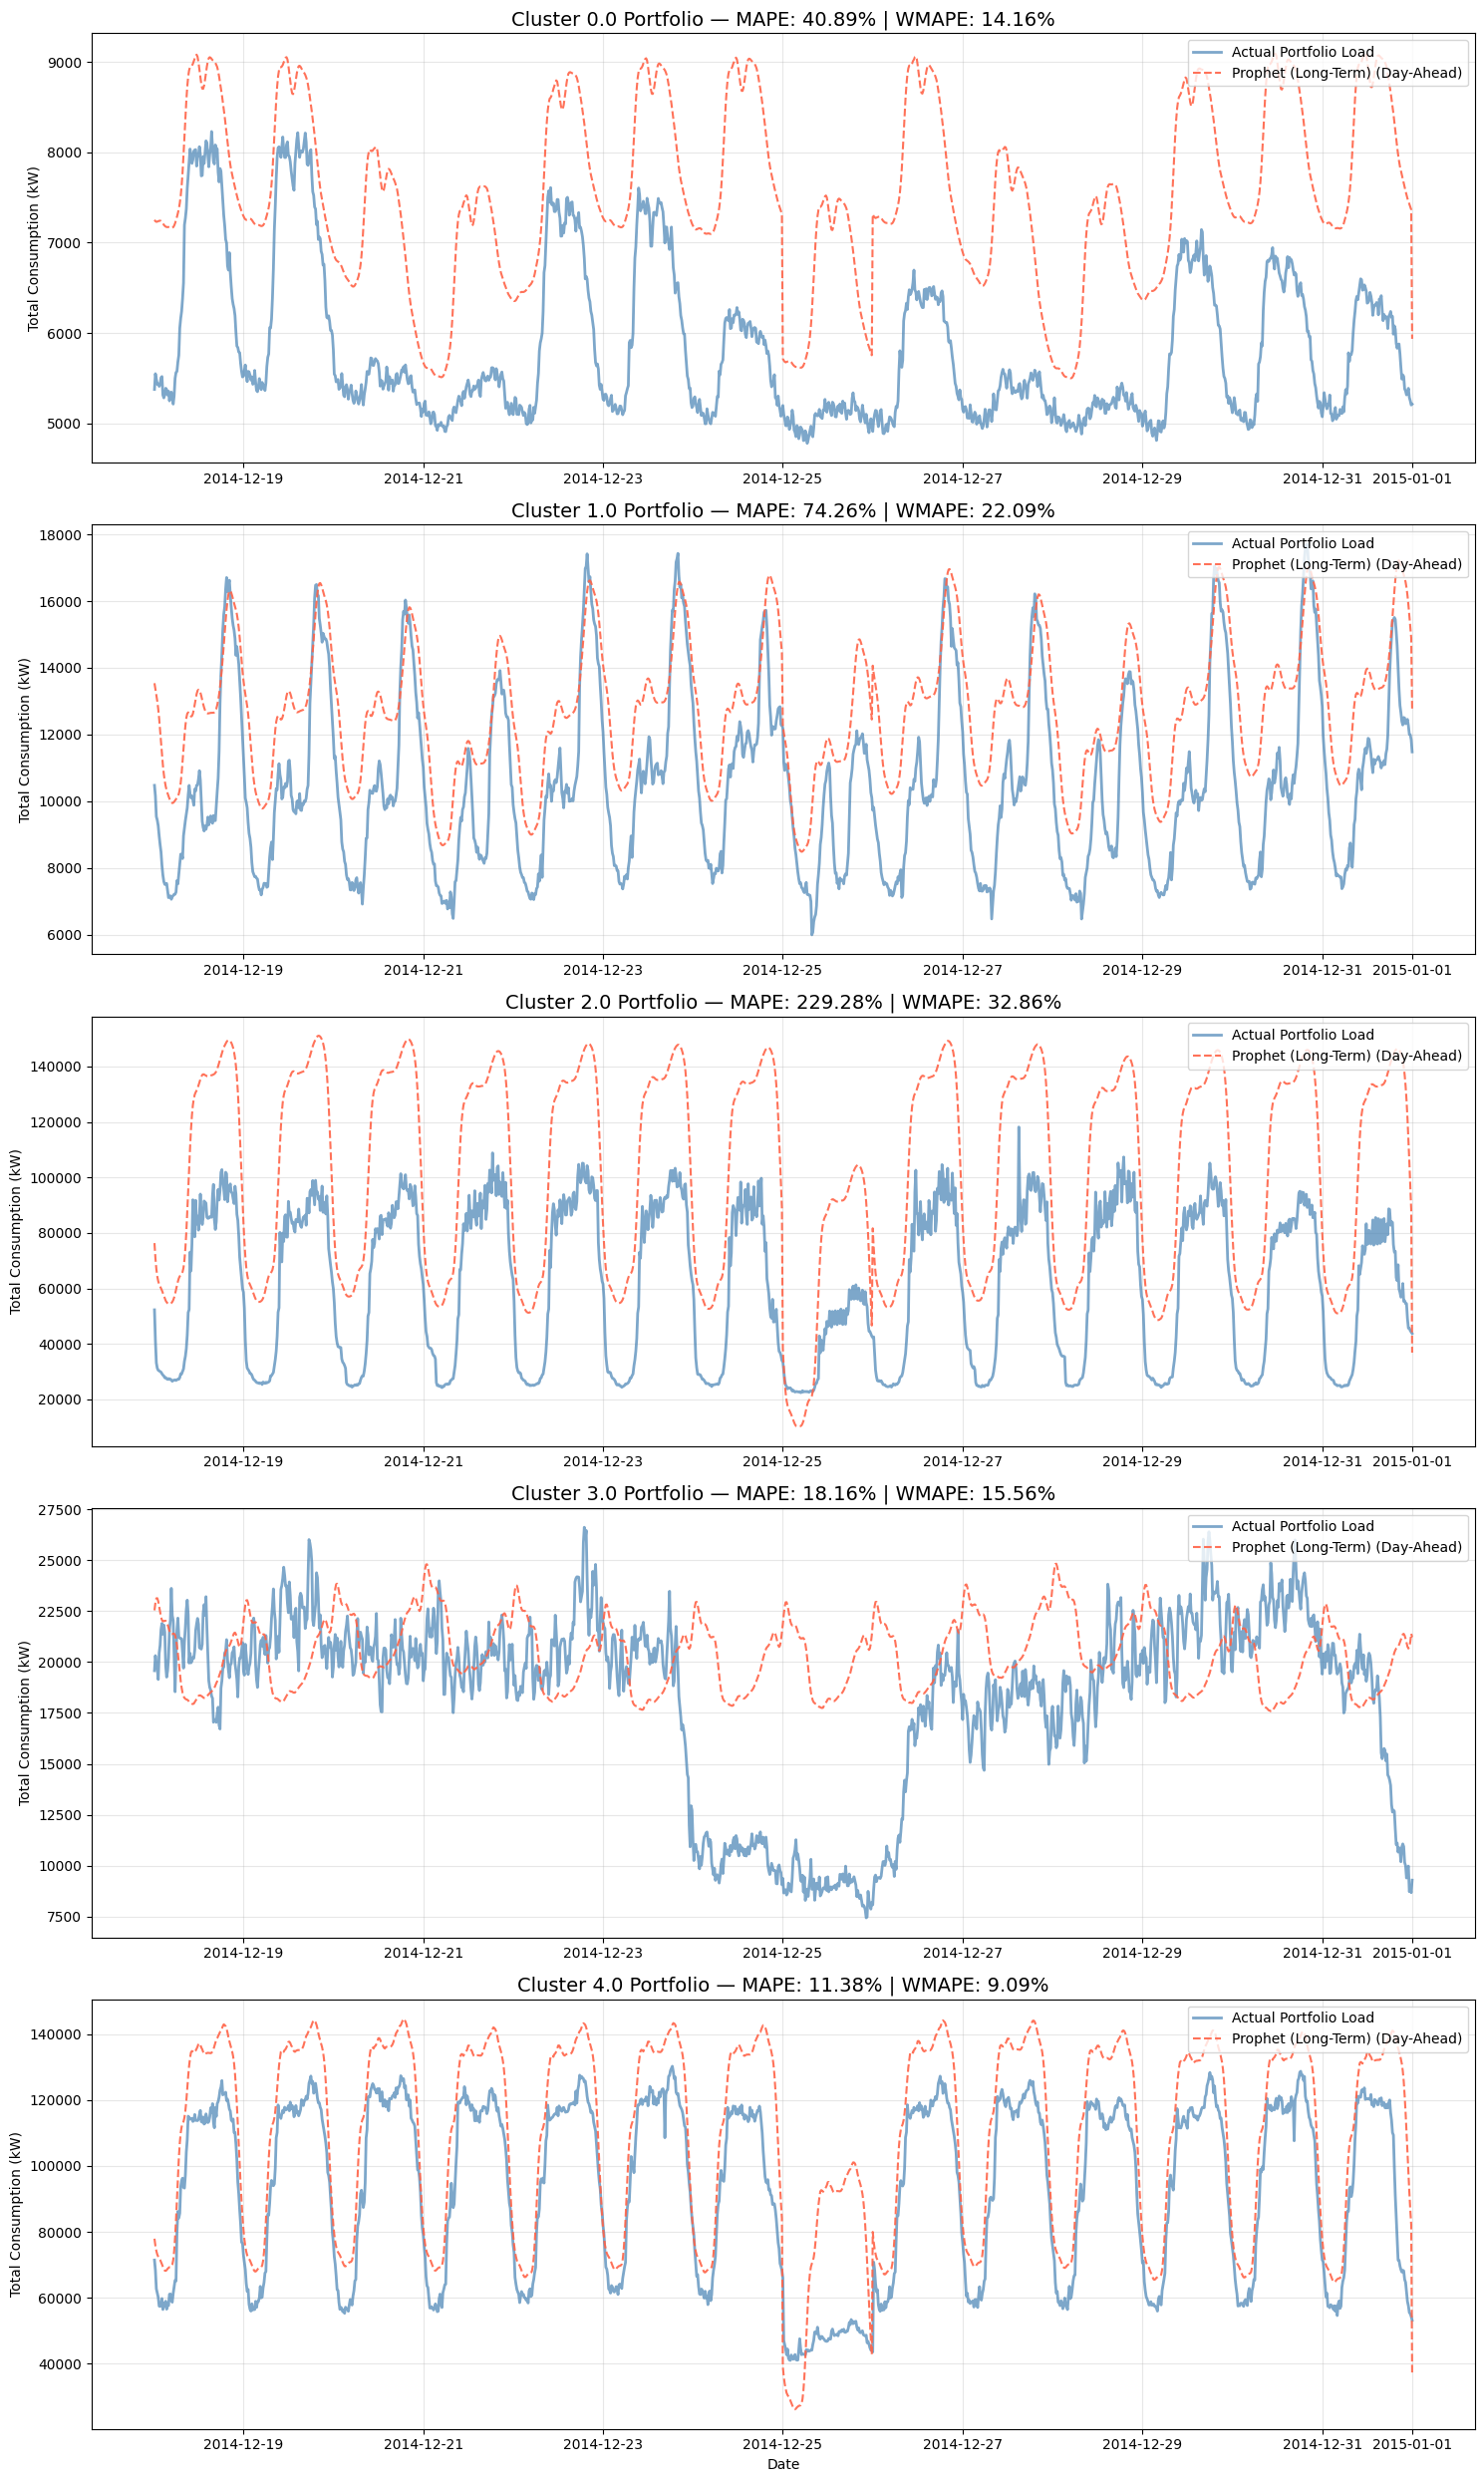

In [4]:
# Visualization for Long-Term results
plot_cluster_portfolio(eval_lt, summary_lt, model_label="Prophet (Long-Term)")

---

## 3. EXPERIMENT B: Day-Ahead Horizon (Weather + Consumption Lags)

In this mode, we provide Prophet with the consumption from 24h ago and 1 week ago. This allows the model to capture the "inertia" of the load, which is critical for precise day-ahead forecasts.

In [5]:
# B.1 Prepare Data (Day Ahead)
train_agg_da, test_agg_da, test_raw_da, scalers_da, sw_da, regs_da = preprocess_and_split(df_long, mode='day_ahead')

# B.2 Train Cluster Models
models_da = train_models(train_agg_da, regs_da)

# B.3 Predict & Un-scale
results_da = predict_models(models_da, test_agg_da, test_raw_da, scalers_da, regs_da)

# B.4 Evaluate
eval_da, summary_da = evaluate_models(results_da)
display(summary_da)

Preparing train/test split and scaling (Mode: DAY_AHEAD)...
Scaling individual clients...


Scaling Clients: 100%|██████████| 369/369 [00:18<00:00, 20.21it/s]


Aggregating data by Cluster for Prophet training...
Training Prophet models for 5 clusters...


Training:   0%|          | 0/5 [00:00<?, ?it/s]12:28:39 - cmdstanpy - INFO - Chain [1] start processing
12:29:03 - cmdstanpy - INFO - Chain [1] done processing
Training:  20%|██        | 1/5 [00:25<01:41, 25.33s/it]12:29:07 - cmdstanpy - INFO - Chain [1] start processing
12:29:32 - cmdstanpy - INFO - Chain [1] done processing
Training:  40%|████      | 2/5 [00:55<01:23, 27.92s/it]12:29:36 - cmdstanpy - INFO - Chain [1] start processing
12:30:03 - cmdstanpy - INFO - Chain [1] done processing
Training:  60%|██████    | 3/5 [01:25<00:58, 29.26s/it]12:30:07 - cmdstanpy - INFO - Chain [1] start processing
12:30:42 - cmdstanpy - INFO - Chain [1] done processing
Training:  80%|████████  | 4/5 [02:04<00:32, 32.88s/it]12:30:46 - cmdstanpy - INFO - Chain [1] start processing
12:31:16 - cmdstanpy - INFO - Chain [1] done processing
Training: 100%|██████████| 5/5 [02:38<00:00, 31.68s/it]


Generating forecasts and un-scaling to raw kW...


Un-scaling Clients: 100%|██████████| 369/369 [00:04<00:00, 91.97it/s] 



Evaluating Portfolio Performance...

--- PROPHET PERFORMANCE BY CLUSTER (BUSINESS ORIENTED) ---

         Portfolio_MAPE  Portfolio_WMAPE
Cluster                                 
0.0               32.12             5.59
1.0               62.53            13.67
2.0              176.82            18.08
3.0               17.50            14.70
4.0                6.16             4.05

Global Portfolio MAPE:  59.03%
Global Portfolio WMAPE: 10.64%


,Portfolio_MAPE,Portfolio_WMAPE
Cluster,,
0.0,32.12,5.59
1.0,62.53,13.67
2.0,176.82,18.08
3.0,17.50,14.70
4.0,6.16,4.05


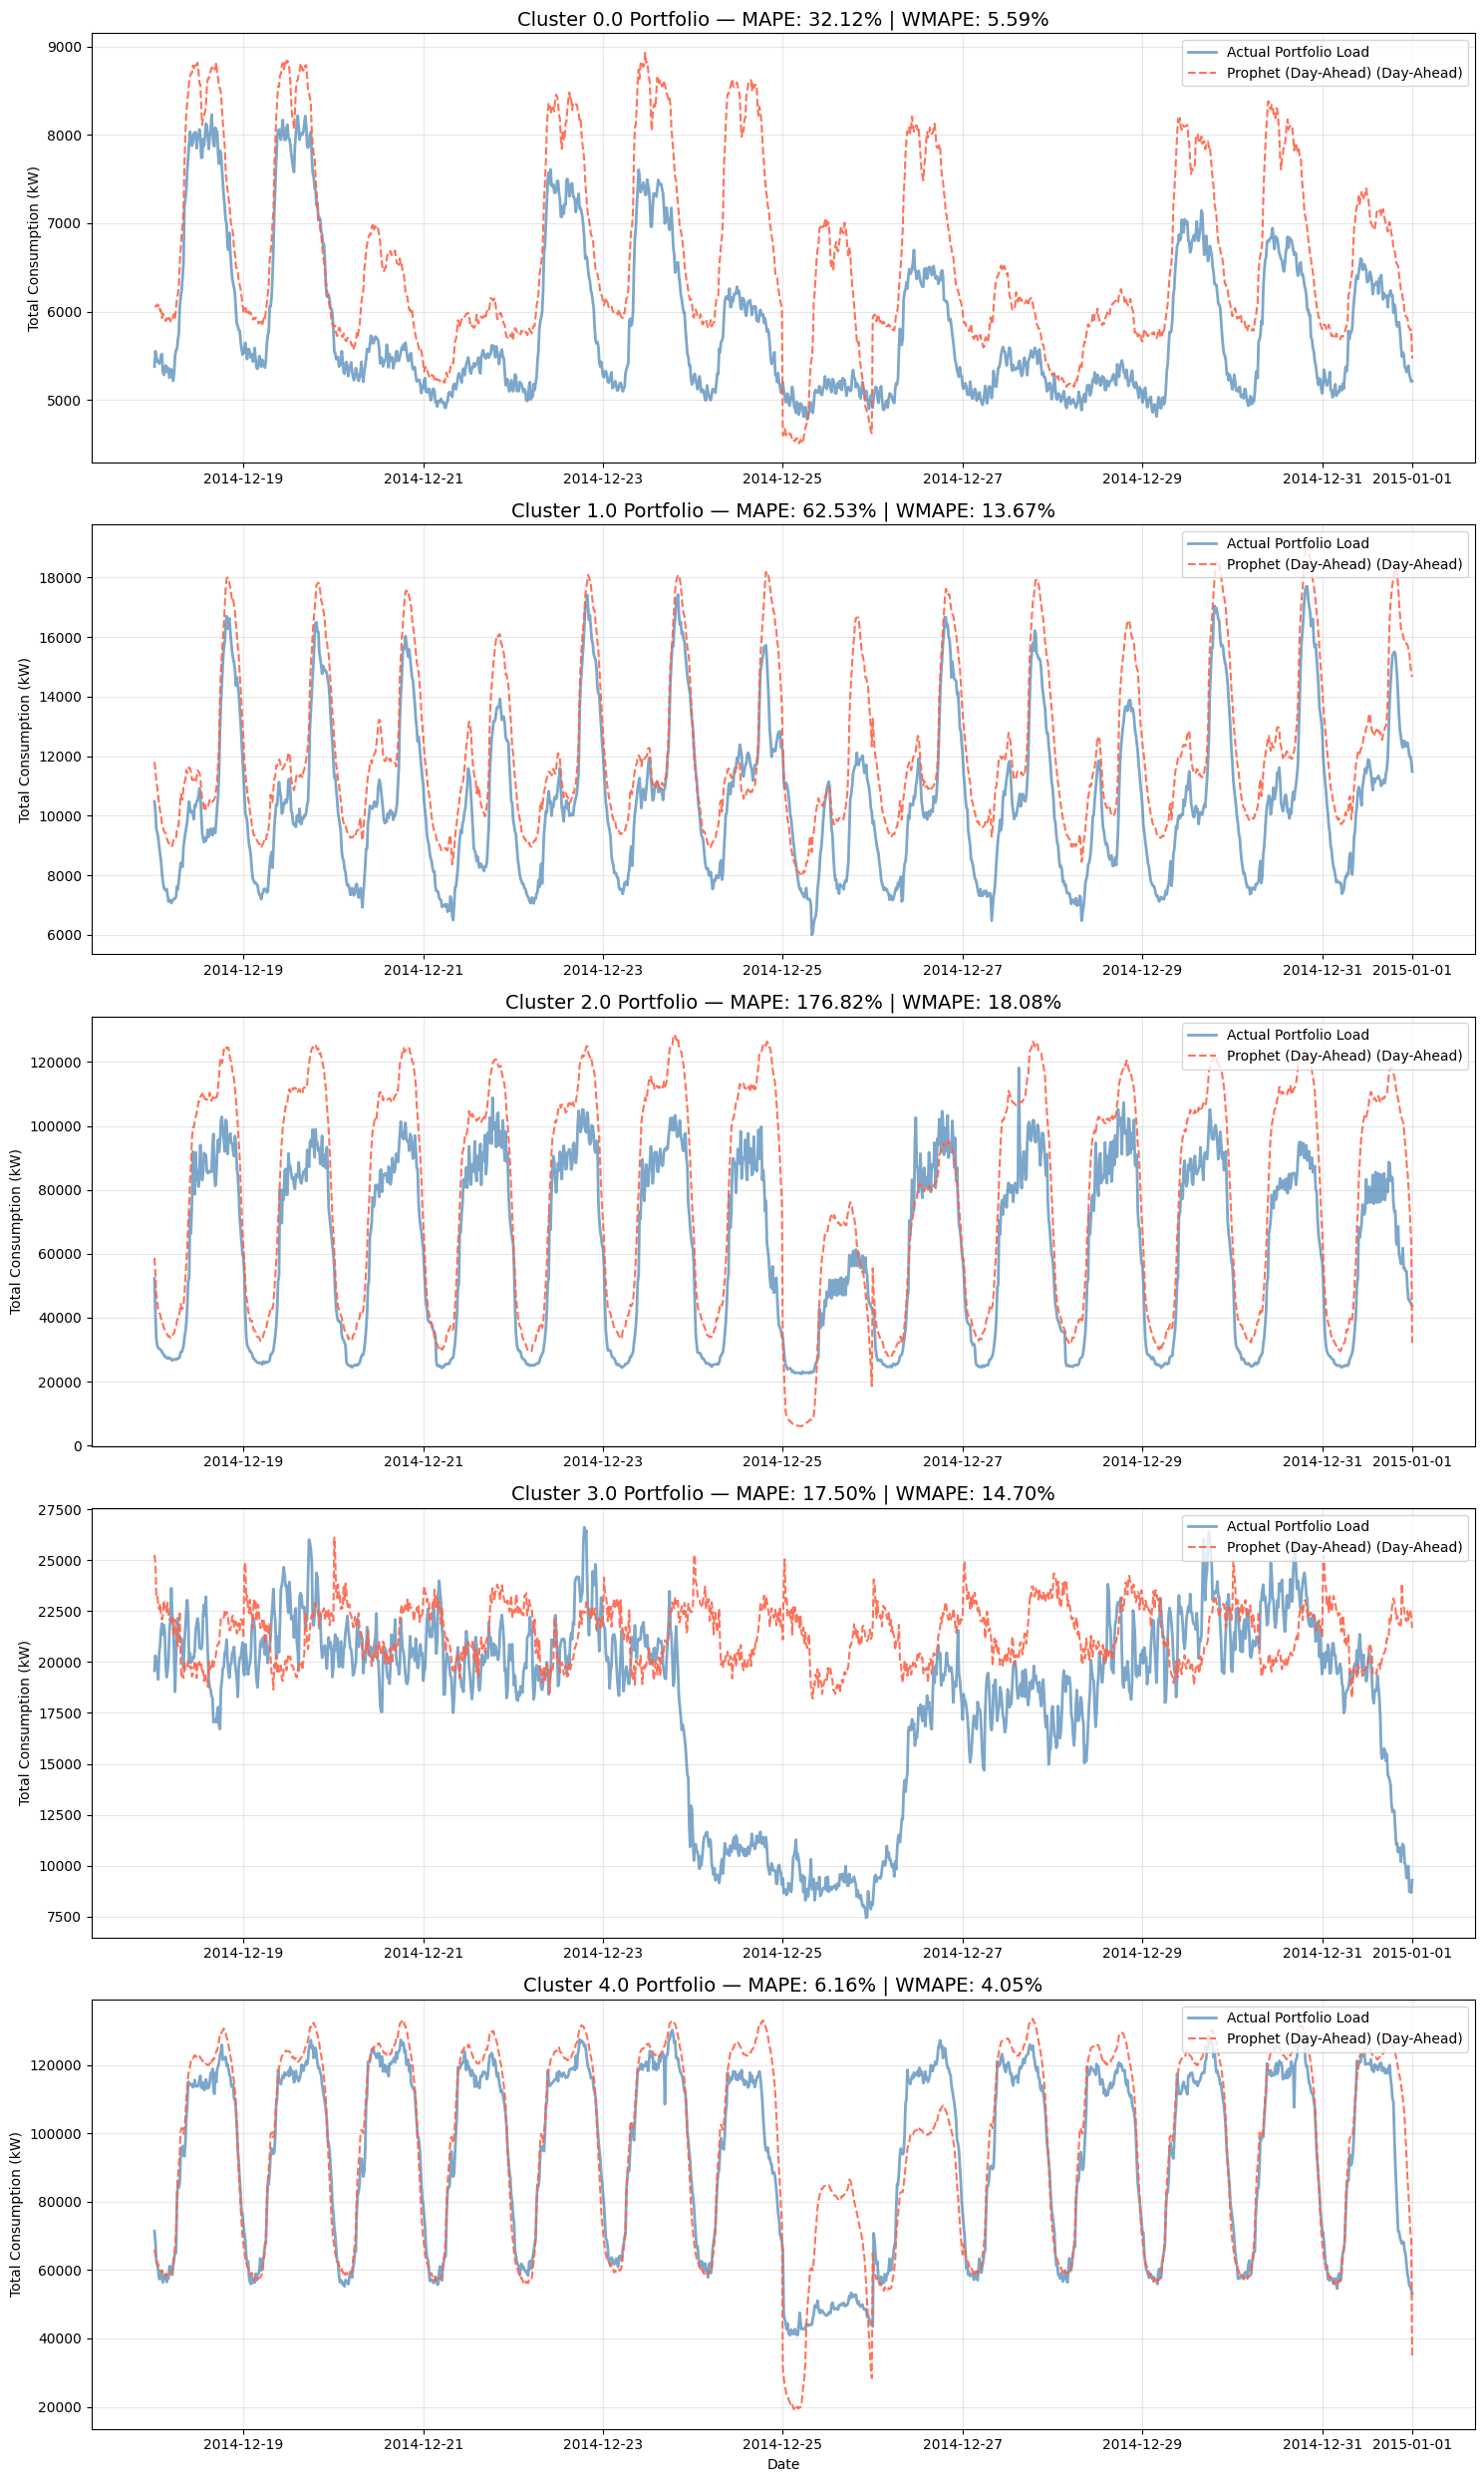

In [6]:
# Visualization for Day-Ahead results
plot_cluster_portfolio(eval_da, summary_da, model_label="Prophet (Day-Ahead)")

---

## 4. Comparison & Insights

Here we compare the performance indicators from both experiments. Typically, the inclusion of consumption lags in the **Day-Ahead** mode significantly reduces the Global WMAPE compared to the purely seasonal **Long-Term** model.

In [7]:
comparison_df = pd.DataFrame({
    "Long-Term (Weather Only)": summary_lt["Portfolio_WMAPE"],
    "Day-Ahead (Weather + Lags)": summary_da["Portfolio_WMAPE"]
}).style.background_gradient(cmap='RdYlGn_r', axis=1)

print("Portfolio WMAPE Comparison by Cluster:")
display(comparison_df)

Portfolio WMAPE Comparison by Cluster:


,Long-Term (Weather Only),Day-Ahead (Weather + Lags)
Cluster,,
0.000000,14.160000,5.590000
1.000000,22.090000,13.670000
2.000000,32.860000,18.080000
3.000000,15.560000,14.700000
4.000000,9.090000,4.050000


### Observations
- **Impact of Lags**: Compare how much the error decreases when adding `Lag_24h` and `Lag_1week` as regressors.
- **Stability**: Check which clusters show the greatest improvement (often industrial clusters or highly volatile profiles benefit more from lags).
- **Next Steps**: Now that the modular Prophet model is validated in both modes, we can save the artifacts for production inference.